### Extract Results from all the models

In [8]:
import os
import regex
import sys
import json

In [ ]:
mm_folders = ["Gemini", "Llama3.2", "Llama4", "Qwen"]

family_model_names = {
    "Gemini": "gemini-2.5-flash",
    "Llama3.2": "Llama-3.2-11B-Vision-Instruct",
    "Llama4": "Llama-4-Scout-17B-16E-Instruct-FP8",
    "Qwen": "Qwen2.5-VL-7B-Instruct"
}

# get the average scores from result files
def get_scores(fname):
    if not os.path.exists(fname):
        print(f"File {fname} does not exist")
        return

    pattern = r'^\|\s([A-Za-z]*)\s+\|\s+([0-9]\.?[0-9]*?)\s+\|\s+([0-9]\.?[0-9]*?)\s+\|'
    match_scores = regex.compile(pattern)
    scores = {}
    with open(fname, 'r') as f:
        lines = f.readlines()
    for line in lines:
        match_pattern = match_scores.match(line)
        if match_pattern:
            facet = match_pattern.group(1).strip()
            avg = match_pattern.group(2)
            # std = match_pattern.group(3)
            scores[facet] = float(avg)
    return scores


In [40]:

mm_results_data = []

# mm_records = []
# for model, scores in mm_result_data.items():
#     if scores:
#         for facet, score in scores.items():
#             mm_records.append({'Model': model, 'Facet': facet, 'Score': score})
# mm_df = pd.DataFrame(mm_records)


for family in mm_folders:
    if "Llama" in family:
        llama_path = "meta-llama"
        facet_scores = get_scores(os.path.join(os.getcwd(), llama_path , f"{family_model_names[family]}_results.md"))
    else:
        facet_scores = get_scores(os.path.join(os.getcwd(), family, f"{family_model_names[family]}_results.md"))
    
    for facet,score in facet_scores.items():
        mm_results_data.append({'Model': family_model_names[family] , 'Facet': facet, 'Score': score}) 

mm_df = pd.DataFrame(mm_results_data)
mm_df

,Model,Facet,Score
0,gemini-2.5-flash,Agreeableness,3.37
1,gemini-2.5-flash,Conscientiousness,3.63
2,gemini-2.5-flash,Extraversion,3.29
3,gemini-2.5-flash,Neuroticism,2.93
4,gemini-2.5-flash,Openness,4.06
5,Llama-3.2-11B-Vision-Instruct,Agreeableness,1.44
6,Llama-3.2-11B-Vision-Instruct,Conscientiousness,3.11
7,Llama-3.2-11B-Vision-Instruct,Extraversion,3.50
8,Llama-3.2-11B-Vision-Instruct,Neuroticism,2.50
9,Llama-3.2-11B-Vision-Instruct,Openness,2.20


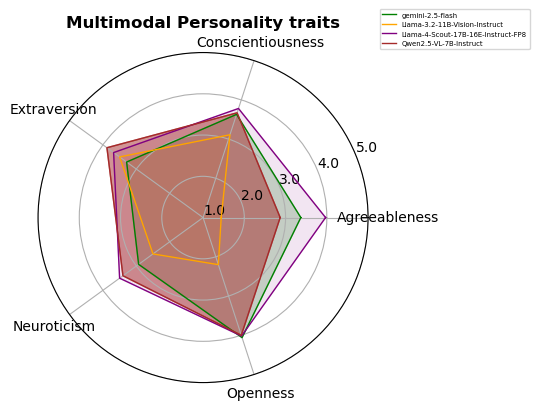

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import re

def sort_by_facets(facets):
    # Keep a sensible order like Type1..Type5 if present; otherwise alphabetical
    def key_fn(s):
        m = re.search(r'(\d+)$', str(s))
        return (str(s), int(m.group(1))) if m else (str(s), 0)
    return sorted(facets, key=key_fn)

def draw_polar_overlay(df, models, facet_order=None, title=None):

    if facet_order is None:
        facet_order = sort_by_facets(df["Facet"].unique())

    # angles around the circle
    N = len(facet_order)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    cmap = ["green","orange", "purple","brown"]  # change colors
    alphas = [0.2, 0.15, 0.1, 0.5]  # transparency levels for fill
    for idx,m in enumerate(models):
        dm = df[df["Model"] == m].set_index("Facet")
        # get values in the chosen facet order
        vals = [dm.loc[f, "Score"] if f in dm.index else np.nan for f in facet_order]
        vals = np.array(vals, dtype=float)

        # close the polygon
        vals_closed = np.concatenate([vals, vals[:1]])
        ang_closed  = np.concatenate([angles, angles[:1]])

        ax.plot(ang_closed, vals_closed, linewidth=1, linestyle='solid', color=cmap[idx], label=m)  
        ax.fill(ang_closed, vals_closed, color=cmap[idx], alpha=alphas[idx])
    

    # radial axis: fixed 1–5 scale
    ax.set_ylim(1.0, 5.0)
    ax.set_yticks([1.0, 2.0, 3.0, 4.0, 5.0])
    ax.set_yticklabels(["1.0", "2.0", "3.0", "4.0", "5.0"])

    # facet labels
    ax.set_xticks(angles)
    ax.set_xticklabels(facet_order)

    if title is None:
        title = models[0].split("-")[0]
    ax.set_title(f"{title} Personality traits", fontdict={'fontsize': 12, 'fontweight': 'bold'})
    

    ax.legend(loc="lower right",fontsize=5 , bbox_to_anchor=(1.5, 1))
    plt.tight_layout()
    figname = f"{title}_overlay_polar.png"
    plt.savefig(figname, dpi=300)
    plt.show()
    
    
models = [v for v in family_model_names.values()]

draw_polar_overlay(mm_df, models=models, title="Multimodal")